# Домашняя работа 3. Логистическая регрессия.

### Оценивание и штрафы

Максимальная оценка — 10 баллов.

Не списывайте, иначе всем участникам обнулим :)

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

Оценка: 10

In [ ]:
print('Всем удачи!👒')

Всем удачи!👒


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

## Логистическая регрессия

Модель логистической регрессии:
  $$
  \hat y = \sigma (Xw).
  $$
  Сигмоида меняется в пределах от 0 до 1 и имеет вид:
  $$
  \sigma(x) = \frac{1}{1+e^{-x}}.
  $$

  Функция потерь log-loss:
  $$
  L = -\frac{1}{\ell}\sum_{i = 1}^{\ell}(y_i\log(\hat y_i) + (1 - y_i)\log(1 - \hat y_i)),
  $$
  где $\ell$ - количество объектов.

## Градиентный спуск

Итеративный метод оптимизации, при котором вектор весов модели $\mathbf{w}^{(t+1)}$ на шаге $t+1$ может быть выражен как:
$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta_t \nabla L(\mathbf{w}^{(t)}),
$$
где $\eta_t$ - шаг обучения.

## Часть 1. Логрег своими руками

**Задание 1 (8 баллов)**. Реализуйте логистическую регрессию, обучаемую с помощью:
- градиентного спуска **(4 балла)**

- стохастического градиентного спуска **(4 балла)**

Во всех пунктах необходимо соблюдать два условия:
- Циклы можно использовать только для итераций градиентного спуска;
- В качестве критерия останова необходимо использовать (одновременно):

    - проверку на евклидову норму разности весов на двух соседних итерациях (например, меньше некоторого малого числа порядка $10^{-6}$), задаваемого параметром `tolerance`;
    - достижение максимального числа итераций (например, 10000), задаваемого параметром `max_iter`.

Чтобы проследить, что оптимизационный процесс действительно сходится, добавим атрибут класса `loss_history`. В нём после вызова метода `fit` должны содержаться значения функции потерь для всех итераций градиентного спуска, начиная с нулевой.

Инициализировать веса можно случайным образом или нулевым вектором.

In [63]:
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type: str, tolerance: float = 1e-6,
                 max_iter: int = 10000, eta: float = 1e-2,
                 w0: np.array = None) -> None:

        """
        Args:
          gd_type: Type of gradient descent ('full' or 'stochastic').

          tolerance: Threshold for stopping gradient descent.

          max_iter: Maximum number of steps in gradient descent.

          eta: Learning rate.

          w0: Array of shape d (d — number of weights to optimize).
              Initial weights.
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.eta = eta
        self.w0 = w0
        self.w = None
        self.loss_history = None

    def fit(self, X: np.array, y: np.array) -> LogReg:
        """Fit the model on training data. Also, save value of loss after each iteration.

        Args:
          X: Training data.

          y: Target.

        Returns:
          self: Fitted classsifier.
        """
        self.loss_history = []

        if self.w0 is None:
            self.w0 = np.zeros(X.shape[1])

        self.w = self.w0
        for i in range(10000):
            w_new = self.w
            self.w = w_new - self.eta * self.calc_gradient(X, y)
            self.loss_history.append(self.calc_loss(X, y))
            if np.linalg.norm(self.w - w_new) < self.tolerance:
              break
        return self


    def predict_proba(self, X: np.array) -> np.array:
        """Calculate probability of positive and negative class for each observation.
        Args:
          X: Array of shape (n, d).
             Data.

        Returns:
             Array of shape (n, 2).
             Predicted probabilities.
        """
        if self.w is None:
            raise Exception('Not trained yet')

        else:
            y_pos_pred = 1 / (1 + np.exp(-X @ self.w))

        a = np.array([y_pos_pred, 1 - y_pos_pred])
        return np.transpose(a)



    def predict(self, X: np.array) -> np.array:
        """Predict class for each observation.

        Args:
          X: Array of shape (n, d).
             Data.

        Returns:
             Array of shape (n,).
             Predicted class labels.
        """
        if self.w is None:
            raise Exception('Not trained yet')
        else:
            y_pred = np.round(self.predict_proba(X)[:, 0])
        return y_pred

    def calc_gradient(self, X: np.array, y: np.array) -> np.array:
        """Calculate gradient of loss function after each iteration.

        Args:
          X: Array of shape (n, d), n can be equal to 1 if 'stochastic'.
          y: Array of shape (n,).

        Returns:
          Array of shape (d,).
          Gradient of loss function after current iteration.
        """
        if self.gd_type == 'full':
            v_grad = (1 / X.shape[0]) * (np.transpose(X) @ (self.predict_proba(X)[:, 0] - y)) #Данная формула была получена из интернета https://www.dmitrymakarov.ru/opt/logistic-regression-05/
        if self.gd_type == 'stochastic':
            i = np.random.choice(len(y))
            v_grad = (self.predict_proba(X)[i, 0] - y[i]) * X[i, :] #Данная формула была получена из интернета https://www.dmitrymakarov.ru/opt/logistic-regression-05/
        return v_grad

    def calc_loss(self, X: np.array, y: np.array) -> float:
        """Calculate value of loss function after each iteration.

        Args:
          X: Array of shape (n, d).
          y: Array of shape (n,).

        Returns:
          Value of loss function after current iteration.
        """
        Loss_function = (- 1 * np.sum(y * np.log(self.predict_proba(X)[:, 0]) + (1 - y) * np.log(self.predict_proba(X)[:, 1]))) / X.shape[0]
        return Loss_function

Далее предполагается, что вы используете собственную реализацию логистической регрессии.
Если с написанием класса возникли проблемы, используйте реализацию sklearn, чтобы не терять баллы за остальные задания.

Сгенерируем синтетические данные.

In [62]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


**Задание 2 (1 балл).** Обучите логистическую регрессию на синтетических данных. Нарисуйте кривую обучения.

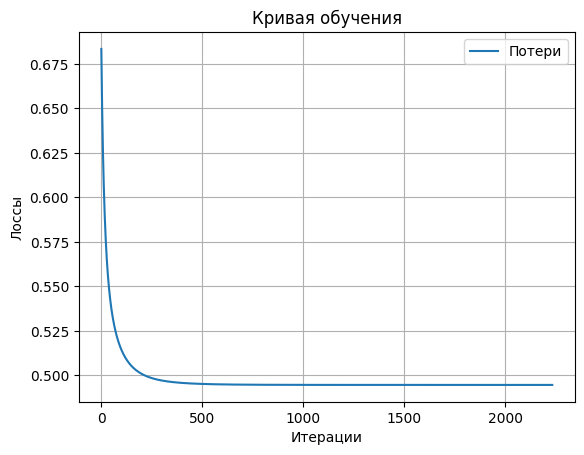

In [61]:

classifier = LogReg(gd_type='full', tolerance=1e-6, max_iter=10000, eta=0.01)
classifier.fit(X_train, y_train)



plt.plot(classifier.loss_history, label="Потери")
plt.title("Кривая обучения")

plt.xlabel("Итерации")
plt.ylabel("Лоссы")

plt.grid()
plt.legend()
plt.show()

На тестовой части посчитайте ROC-AUC, PR-AUC. Постройте ROC и PR кривые.

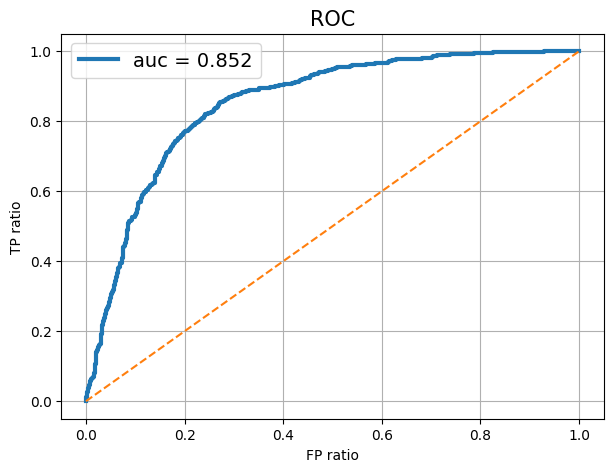

In [60]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

roc_auc = roc_auc = auc(fpr_logreg, tpr_logreg)

y_pred_proba_test = classifier.predict_proba(X_test)[:, 0]

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_proba_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr_logreg, tpr_logreg, linewidth=3, label='auc = {:.3f}'.format(roc_auc))

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('FP ratio', size=10)
plt.ylabel('TP ratio', size=10)

plt.legend(loc='best', fontsize=14)
plt.title('ROC', size=15)
plt.grid()
plt.show()


PR Curve:

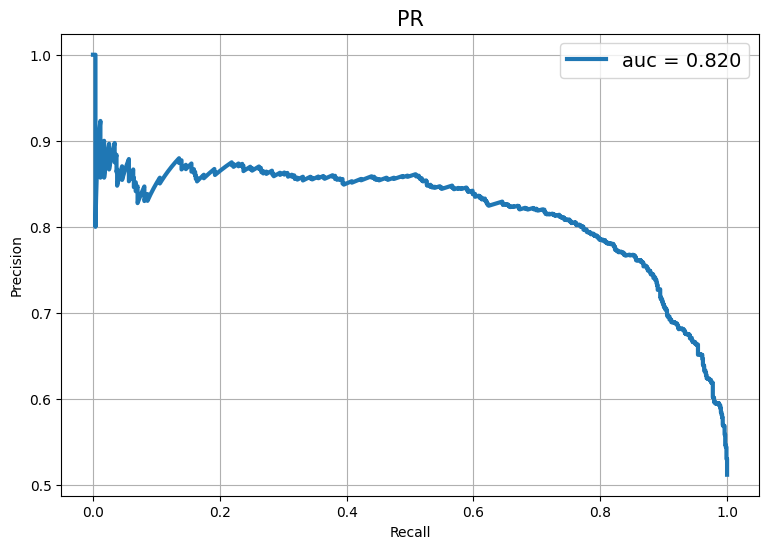

In [59]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_pred_proba_test)
pr_auc = auc(recall_logreg, precision_logreg)

plt.figure(figsize=(9, 6))
plt.plot(recall_logreg, precision_logreg, linewidth=3, label='auc = {:.3f}'.format(pr_auc))

plt.xlabel('Recall', size=10)
plt.ylabel('Precision', size=10)

plt.legend(loc='best', fontsize=14)
plt.title('PR', size=15)
plt.grid()
plt.show()

ROC-AUC и PR-AUC:


**Задание 3 (1 балл).** Оцените ошибку ROC-AUC и PR-AUC вашей модели при помощи K-fold кросс валидации.  

In [58]:
from sklearn.model_selection import KFold

k_f = KFold(n_splits=5)

roc_auc_folds = []
pr_auc_folds = []

for train_index, test_index in k_f.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    classifier.fit(X_train, y_train)
    y_pred_proba_test = classifier.predict_proba(X_test)[:, 0]

    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_proba_test)
    precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_pred_proba_test)

    roc_auc = auc(fpr_logreg, tpr_logreg)
    roc_auc_folds.append(roc_auc)

    pr_auc = auc(recall_logreg, precision_logreg)
    pr_auc_folds.append(pr_auc)



print('ROC_AUC =', roc_auc_folds)
print('Mean_roc_auc =', np.mean(roc_auc_folds))

print('PR_AUC =', pr_auc_folds)
print('Mean_pr_auc =', np.mean(pr_auc_folds))

ROC_AUC = [0.848621394485578, 0.8505896553068977, 0.8383374388300984, 0.8534144326800331, 0.851530481557377]
Mean_roc_auc = 0.8484986805719968
PR_AUC = [0.8149704967589575, 0.8135560637070156, 0.796528233197729, 0.803265013463662, 0.8199920571044774]
Mean_pr_auc = 0.8096623728463683
